Evaluate one already-frozen checkpoint against the three expert-agreement splits.

In [1]:
import os
from pathlib import Path

from ai4mars import acquire_frozen_checkpoint, run_sealed_expert_evaluation

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'pyproject.toml').is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent

configured_dataset = os.environ.get('AI4MARS_DATASET_ROOT')
if configured_dataset:
    DATASET_ROOT = Path(configured_dataset)
else:
    local_dataset = PROJECT_ROOT / 'data' / 'raw' / 'ai4mars' / 'ai4mars-dataset-merged-0.6'
    matches = [local_dataset] if local_dataset.is_dir() else list(Path('/kaggle/input').glob('**/ai4mars-dataset-merged-0.6'))
    if len(matches) != 1:
        raise RuntimeError('Set AI4MARS_DATASET_ROOT to the extracted AI4Mars merged 0.6 directory.')
    DATASET_ROOT = matches[0]

CONFIG_PATH = PROJECT_ROOT / 'configs' / 'reproduction' / 'paper_deeplabv3plus_kaggle_p100.yaml'
MANIFEST_ROOT = PROJECT_ROOT / 'artifacts' / 'manifests'
OUTPUT_ROOT = PROJECT_ROOT / 'outputs' / 'expert-evaluation'
CHECKPOINT_PATH = PROJECT_ROOT / 'artifacts' / 'ai4mars-paper-reproduction' / 'frozen' / 'deeplabv3plus-tesla-p100-seed42-best-val-miou.pth'
checkpoint = acquire_frozen_checkpoint(CHECKPOINT_PATH)
print('Frozen checkpoint verified')
print(f'  Path: {checkpoint.path}')
print(f'  Epoch: {checkpoint.epoch}')
print(f'  SHA-256: {checkpoint.sha256}')

Frozen checkpoint verified
  Path: c:\Users\Jacob\AI4Mars\artifacts\ai4mars-paper-reproduction\frozen\deeplabv3plus-tesla-p100-seed42-best-val-miou.pth
  Epoch: 25
  SHA-256: 90e74a9071d9bfb180d80ab2bb1927f1ea83a74d7e0601750873c2547a5ddaa3


In [4]:
run_dir = run_sealed_expert_evaluation(
    config_path=CONFIG_PATH,
    checkpoint_path=CHECKPOINT_PATH,
    dataset_root=DATASET_ROOT,
    manifest_root=MANIFEST_ROOT,
    output_root=OUTPUT_ROOT,
    device='auto',
)
print(f'Completed sealed evaluation: {run_dir}')

Completed sealed evaluation: c:\Users\Jacob\AI4Mars\outputs\expert-evaluation\runs\ai4mars-baseline


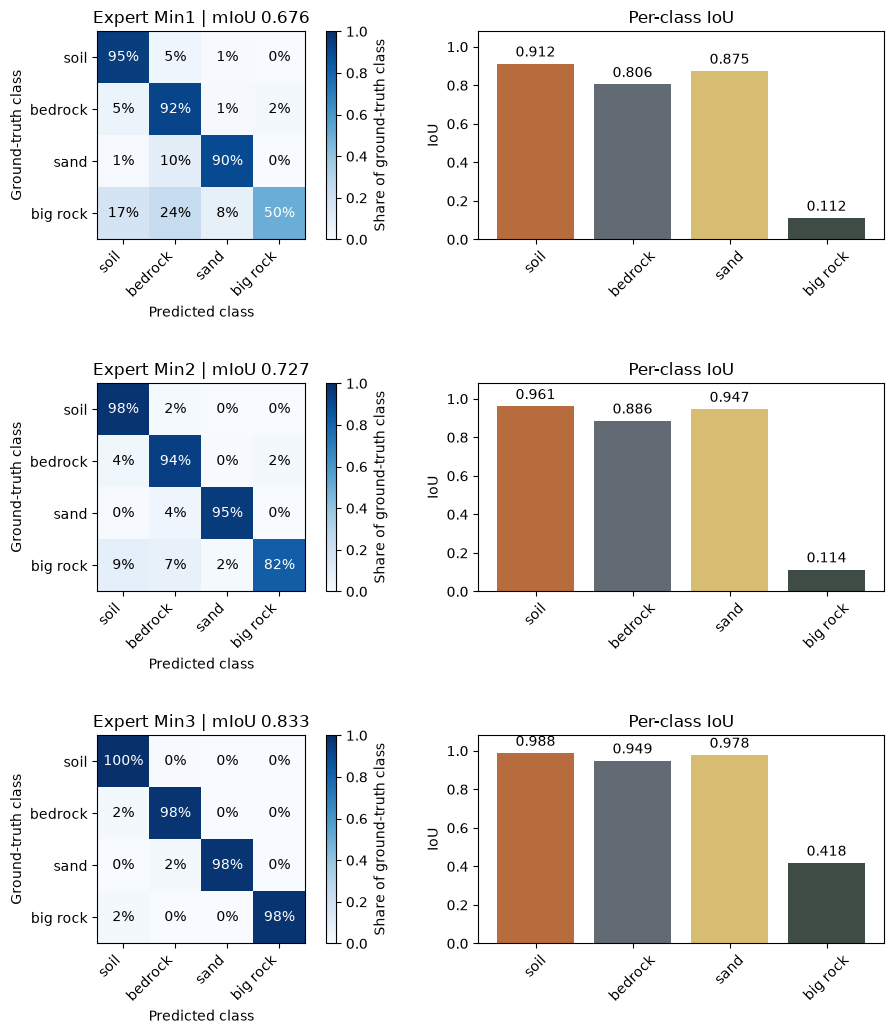

In [9]:
import base64
import json
from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

report = json.loads(
    (run_dir / "artifacts" / "expert_evaluation.json").read_text(encoding="utf-8")
)
class_names = ("soil", "bedrock", "sand", "big rock")
split_items = list(report["splits"].items())

figure, axes = plt.subplots(
    len(split_items),
    2,
    figsize=(10, 3.5 * len(split_items)),
    constrained_layout=True,
)
figure.set_constrained_layout_pads(
    w_pad=0.08,
    h_pad=0.18,
    wspace=0.08,
    hspace=0.12,
)

for row, (split_name, metrics) in zip(axes, split_items):
    confusion_axis, iou_axis = row

    matrix = np.asarray(metrics["normalized_confusion_matrix"], dtype=float)
    image = confusion_axis.imshow(matrix, vmin=0.0, vmax=1.0, cmap="Blues")
    confusion_axis.set_title(
        f"{split_name.replace('_', ' ').title()} | mIoU {metrics['mean_iou']:.3f}"
    )
    confusion_axis.set_xlabel("Predicted class")
    confusion_axis.set_ylabel("Ground-truth class")
    confusion_axis.set_xticks(range(len(class_names)), class_names, rotation=45, ha="right")
    confusion_axis.set_yticks(range(len(class_names)), class_names)

    for row_index in range(matrix.shape[0]):
        for column_index in range(matrix.shape[1]):
            value = matrix[row_index, column_index]
            confusion_axis.text(
                column_index,
                row_index,
                f"{value:.0%}",
                ha="center",
                va="center",
                color="white" if value >= 0.5 else "black",
            )

    figure.colorbar(image, ax=confusion_axis, label="Share of ground-truth class")

    ious = [class_metrics["iou"] for class_metrics in metrics["per_class"]]
    bars = iou_axis.bar(class_names, ious, color=["#b86b3d", "#626b73", "#d6bd72", "#3f4c45"])
    iou_axis.set_title("Per-class IoU")
    iou_axis.set_ylabel("IoU")
    iou_axis.set_ylim(0.0, 1.08)
    iou_axis.tick_params(axis="x", rotation=45)

    for bar, iou in zip(bars, ious):
        iou_axis.text(
            bar.get_x() + bar.get_width() / 2,
            iou + 0.02,
            f"{iou:.3f}",
            ha="center",
            va="bottom",
        )

image_buffer = BytesIO()
figure.savefig(image_buffer, format="png", dpi=100, bbox_inches="tight")
plt.close(figure)
display({"image/png": base64.b64encode(image_buffer.getvalue()).decode("ascii")}, raw=True)

Terrain source: NLB_577090763EDR_F0691858NCAM00287M1 (F0691858NCAM00287M1)
Big-rock source: NLB_556756308EDR_F0651642NCAM00285M1 (F0651642NCAM00285M1)
Big Rock share of valid Min3 pixels: 12.6%
Min3 big-rock pixels: 60,765


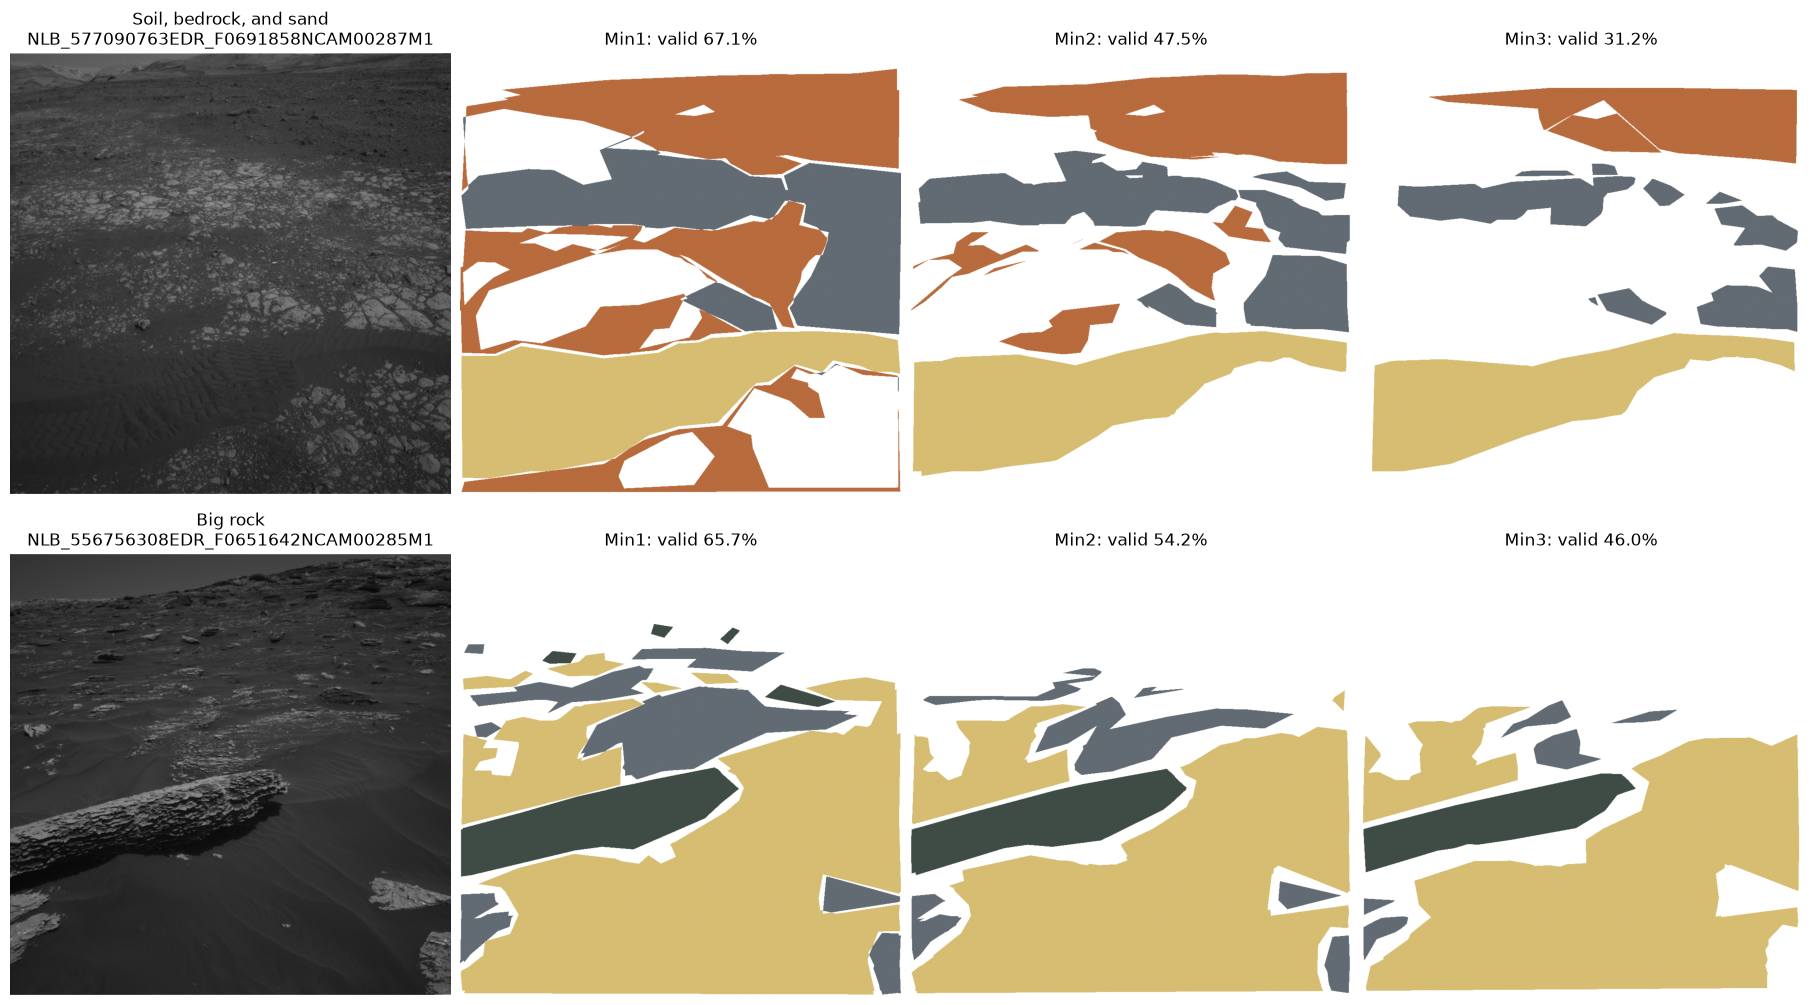

In [ ]:
import csv
import json

from PIL import Image
from matplotlib.colors import ListedColormap

min3_manifest = (
    MANIFEST_ROOT
    / "splits"
    / "msl_navcam_v1"
    / "test_min3_100agree_nav.csv"
)

terrain_candidates = []
big_rock_candidates = []

with min3_manifest.open(encoding="utf-8", newline="") as stream:
    for row in csv.DictReader(stream):
        counts = {
            int(label): int(count)
            for label, count in json.loads(row["per_class_pixel_counts_json"]).items()
        }
        source_id = row["stable_source_image_id"]

        if all(counts.get(label, 0) > 0 for label in (0, 1, 2)):
            if counts.get(3, 0) == 0:
                terrain_candidates.append(
                    (
                        min(counts[label] for label in (0, 1, 2)),
                        source_id,
                        row["sequence_id"],
                    )
                )

        if counts.get(3, 0) > 0:
            big_rock_candidates.append(
                (
                    float(row["valid_pixel_fraction"]),
                    counts[3],
                    source_id,
                    row["sequence_id"],
                )
            )

_, terrain_source_id, terrain_sequence_id = max(terrain_candidates)

different_sequence_big_rock_candidates = [
    candidate
    for candidate in big_rock_candidates
    if candidate[3] != terrain_sequence_id
]

big_rock_share, big_rock_pixels, big_rock_source_id, big_rock_sequence_id = max(
    different_sequence_big_rock_candidates
)

print(f"Terrain source: {terrain_source_id} ({terrain_sequence_id})")
print(f"Big-rock source: {big_rock_source_id} ({big_rock_sequence_id})")
print(f"Big Rock share of valid Min3 pixels: {big_rock_share:.1%}")
print(f"Min3 big-rock pixels: {big_rock_pixels:,}")

source_rows = [
    ("Soil, bedrock, and sand", terrain_source_id),
    ("Big rock", big_rock_source_id),
]

colors = ["#b86b3d", "#626b73", "#d6bd72", "#3f4c45"]
label_map = ListedColormap(colors)
label_map.set_bad(alpha=0)

figure, axes = plt.subplots(
    len(source_rows),
    4,
    figsize=(18, 10),
    constrained_layout=True,
)

for axis_row, (row_name, source_id) in zip(axes, source_rows):
    image_path = DATASET_ROOT / "msl/ncam/images/edr" / f"{source_id}.JPG"
    mask_paths = {
        "Min1": DATASET_ROOT / "msl/ncam/labels/test/masked-gold-min1-100agree" / f"{source_id}_merged.png",
        "Min2": DATASET_ROOT / "msl/ncam/labels/test/masked-gold-min2-100agree" / f"{source_id}_merged.png",
        "Min3": DATASET_ROOT / "msl/ncam/labels/test/masked-gold-min3-100agree" / f"{source_id}_merged.png",
    }

    axis_row[0].imshow(Image.open(image_path).convert("RGB"))
    axis_row[0].set_title(f"{row_name}\n{source_id}")

    for axis, (name, path) in zip(axis_row[1:], mask_paths.items()):
        mask = np.asarray(Image.open(path))
        visible_mask = np.ma.masked_equal(mask, 255)
        axis.imshow(visible_mask, cmap=label_map, vmin=0, vmax=3)
        axis.set_title(f"{name}: valid {(mask != 255).mean():.1%}")

    for axis in axis_row:
        axis.axis("off")

plt.show()